In [2]:
from pathlib import Path
import json
import copy
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import roc_auc_score, accuracy_score
import sys
from pathlib import Path

PROJECT_ROOT = Path("../../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.biomarkers.ft_transformer import (
    BiomarkerFTTransformer
)

print("PyTorch:", torch.__version__)

PyTorch: 2.14.0+cu130


In [3]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "CUDA:",
        torch.version.cuda
    )

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 13.0


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


In [5]:
PROJECT_ROOT = Path("../../").resolve()

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "biomarkers"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "biomarkers"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed:", PROCESSED_DIR)
print("Checkpoints:", CHECKPOINT_DIR)

Processed: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\processed\biomarkers
Checkpoints: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\biomarkers


In [6]:
DATASETS = {
    "zheen": {
        "target_map": {
            "target": "acute_mi",
        }
    },

    "uci_heart_failure": {
        "target_map": {
            "DEATH_EVENT": "hf_mortality",
        }
    },

    "mi_complications": {
        "target_map": {
            "FIBR_PREDS": "post_mi_af",
            "PREDS_TAH": "post_mi_svt",
            "JELUD_TAH": "post_mi_vt",
            "FIBR_JELUD": "post_mi_vf",
            "A_V_BLOK": "post_mi_av_block",
            "OTEC_LANC": "post_mi_pulmonary_edema",
            "RAZRIV": "post_mi_myocardial_rupture",
            "DRESSLER": "post_mi_dressler",
            "ZSN": "post_mi_chronic_hf",
            "REC_IM": "post_mi_recurrent_mi",
            "P_IM_STEN": "post_mi_angina",
            "LET_IS": "post_mi_mortality_cause",
        }
    },

    "framingham": {
        "target_map": {
            "TenYearCHD": "ten_year_chd_risk",
        }
    },
}

print("Configured datasets:")
for name in DATASETS:
    print("-", name)

Configured datasets:
- zheen
- uci_heart_failure
- mi_complications
- framingham


In [7]:
data = {}

for dataset_name, config in DATASETS.items():

    dataset_dir = (
        PROCESSED_DIR / dataset_name
    )

    X_train = np.load(
        dataset_dir / "X_train.npy"
    )

    X_val = np.load(
        dataset_dir / "X_val.npy"
    )

    X_test = np.load(
        dataset_dir / "X_test.npy"
    )

    y_train = pd.read_csv(
        dataset_dir / "y_train.csv"
    )

    y_val = pd.read_csv(
        dataset_dir / "y_val.csv"
    )

    y_test = pd.read_csv(
        dataset_dir / "y_test.csv"
    )

    target_map = config["target_map"]

    y_train = y_train.rename(
        columns=target_map
    )

    y_val = y_val.rename(
        columns=target_map
    )

    y_test = y_test.rename(
        columns=target_map
    )

    data[dataset_name] = {
        "X_train": X_train.astype(np.float32),
        "X_val": X_val.astype(np.float32),
        "X_test": X_test.astype(np.float32),

        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }

    print(
        f"{dataset_name:22} "
        f"train={X_train.shape} "
        f"val={X_val.shape} "
        f"test={X_test.shape}"
    )

zheen                  train=(923, 8) val=(198, 8) test=(198, 8)
uci_heart_failure      train=(209, 11) val=(45, 11) test=(45, 11)
mi_complications       train=(1190, 113) val=(255, 113) test=(255, 113)
framingham             train=(2968, 15) val=(636, 15) test=(636, 15)


In [8]:
for name, item in data.items():

    print(
        f"{name:22} "
        f"features={item['X_train'].shape[1]} "
        f"targets={list(item['y_train'].columns)}"
    )

zheen                  features=8 targets=['acute_mi']
uci_heart_failure      features=11 targets=['hf_mortality']
mi_complications       features=113 targets=['post_mi_af', 'post_mi_svt', 'post_mi_vt', 'post_mi_vf', 'post_mi_av_block', 'post_mi_myocardial_rupture', 'post_mi_dressler', 'post_mi_chronic_hf', 'post_mi_recurrent_mi', 'post_mi_angina', 'post_mi_mortality_cause']
framingham             features=15 targets=['ten_year_chd_risk']


In [9]:
MULTICLASS_TARGETS = {
    "post_mi_mortality_cause",
}

target_specs = {}

for dataset_name, item in data.items():

    for target in item["y_train"].columns:

        if target in MULTICLASS_TARGETS:

            values = item["y_train"][target].dropna()
            classes = sorted(
                values.astype(int).unique().tolist()
            )

            target_specs[target] = {
                "type": "multiclass",
                "classes": classes,
                "num_classes": len(classes),
            }

        else:

            target_specs[target] = {
                "type": "binary",
                "num_classes": 1,
            }

print(json.dumps(
    target_specs,
    indent=2
))

{
  "acute_mi": {
    "type": "binary",
    "num_classes": 1
  },
  "hf_mortality": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_af": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_svt": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_vt": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_vf": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_av_block": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_myocardial_rupture": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_dressler": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_chronic_hf": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_recurrent_mi": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_angina": {
    "type": "binary",
    "num_classes": 1
  },
  "post_mi_mortality_cause": {
    "type": "multiclass",
    "classes": [
      0,
      1,
      2,
      3,
      4,
      5,
      6,
      7
    ],
   

In [10]:
class_mappings = {}

for target, spec in target_specs.items():

    if spec["type"] != "multiclass":
        continue

    classes = spec["classes"]

    class_mappings[target] = {
        int(original): index
        for index, original in enumerate(classes)
    }

print("Multiclass mappings:")
print(class_mappings)

Multiclass mappings:
{'post_mi_mortality_cause': {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}}


In [11]:
for dataset_name, item in data.items():

    for target, mapping in class_mappings.items():

        for split in [
            "y_train",
            "y_val",
            "y_test",
        ]:

            df = item[split]

            if target not in df.columns:
                continue

            df[target] = (
                df[target]
                .map(mapping)
            )

            item[split] = df

print("Target mappings applied.")

Target mappings applied.


In [12]:
class BiomarkerDataset(Dataset):

    def __init__(
        self,
        X,
        y,
    ):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = y.reset_index(
            drop=True
        )

        self.targets = list(
            self.y.columns
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):

        x = self.X[index]

        targets = {}

        for target in self.targets:

            value = self.y.iloc[
                index
            ][target]

            if pd.isna(value):

                if target in MULTICLASS_TARGETS:
                    targets[target] = torch.tensor(
                        -1,
                        dtype=torch.long
                    )
                else:
                    targets[target] = torch.tensor(
                        float("nan"),
                        dtype=torch.float32
                    )

            elif target in MULTICLASS_TARGETS:

                targets[target] = torch.tensor(
                    int(value),
                    dtype=torch.long
                )

            else:

                targets[target] = torch.tensor(
                    float(value),
                    dtype=torch.float32
                )

        return x, targets

In [13]:
BATCH_SIZE = 64

loaders = {
    "train": {},
    "val": {},
    "test": {},
}

for dataset_name, item in data.items():

    train_dataset = BiomarkerDataset(
        item["X_train"],
        item["y_train"]
    )

    val_dataset = BiomarkerDataset(
        item["X_val"],
        item["y_val"]
    )

    test_dataset = BiomarkerDataset(
        item["X_test"],
        item["y_test"]
    )

    if (
        dataset_name == "framingham"
        and "ten_year_chd_risk"
        in item["y_train"].columns
    ):

        y = (
            item["y_train"]["ten_year_chd_risk"]
            .fillna(0)
            .astype(int)
            .to_numpy()
        )

        class_counts = np.bincount(y)

        weights = np.zeros_like(
            y,
            dtype=np.float64
        )

        for cls in np.unique(y):
            weights[y == cls] = (
                1.0 / class_counts[cls]
            )

        sampler = WeightedRandomSampler(
            torch.tensor(weights, dtype=torch.double),
            num_samples=len(weights),
            replacement=True,
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            sampler=sampler,
        )

    else:

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
        )

    loaders["train"][dataset_name] = train_loader

    loaders["val"][dataset_name] = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    loaders["test"][dataset_name] = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

print("DataLoaders created.")

DataLoaders created.


In [14]:
input_dimensions = {
    dataset_name: item["X_train"].shape[1]
    for dataset_name, item in data.items()
}

model = BiomarkerFTTransformer(
    input_dimensions=input_dimensions,
    target_specs=target_specs,
    d_token=64,
    n_heads=4,
    n_layers=3,
    dropout=0.20,
).to(DEVICE)

print(model)

D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\src\models\biomarkers\ft_transformer.py:81: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


BiomarkerFTTransformer(
  (adapters): ModuleDict(
    (zheen): SourceInputAdapter(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (uci_heart_failure): SourceInputAdapter(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (mi_complications): SourceInputAdapter(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (framingham): SourceInputAdapter(
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
     

In [15]:
binary_pos_weights = {}

multiclass_weights = {}

for target, spec in target_specs.items():

    values = []

    for dataset_name, item in data.items():

        if target in item["y_train"].columns:

            values.extend(
                item["y_train"][target]
                .dropna()
                .tolist()
            )

    values = np.asarray(values)

    if spec["type"] == "binary":

        positive = np.sum(values == 1)
        negative = np.sum(values == 0)

        if positive > 0:
            binary_pos_weights[target] = (
                negative / positive
            )
        else:
            binary_pos_weights[target] = 1.0

    else:

        classes = np.arange(
            spec["num_classes"]
        )

        counts = np.array([
            np.sum(values == cls)
            for cls in classes
        ])

        counts = np.maximum(
            counts,
            1
        )

        weights = (
            counts.sum() / counts
        )

        weights = (
            weights / weights.mean()
        )

        multiclass_weights[target] = (
            torch.tensor(
                weights,
                dtype=torch.float32,
                device=DEVICE
            )
        )

print("Binary positive weights:")
print(binary_pos_weights)

print("\nMulticlass weights:")
print(multiclass_weights)

Binary positive weights:
{'acute_mi': np.float64(0.6221441124780316), 'hf_mortality': np.float64(2.542372881355932), 'post_mi_af': np.float64(9.530973451327434), 'post_mi_svt': np.float64(78.33333333333333), 'post_mi_vt': np.float64(35.06060606060606), 'post_mi_vf': np.float64(24.869565217391305), 'post_mi_av_block': np.float64(28.75), 'post_mi_myocardial_rupture': np.float64(30.31578947368421), 'post_mi_dressler': np.float64(24.869565217391305), 'post_mi_chronic_hf': np.float64(3.2652329749103943), 'post_mi_recurrent_mi': np.float64(9.17094017094017), 'post_mi_angina': np.float64(10.553398058252426), 'ten_year_chd_risk': np.float64(5.610244988864142)}

Multiclass weights:
{'post_mi_mortality_cause': tensor([0.0192, 0.2530, 1.2818, 0.5060, 1.3734, 2.4035, 0.9614, 1.2017],
       device='cuda:0')}


In [16]:
def compute_loss(
    outputs,
    targets,
):
    total_loss = torch.tensor(
        0.0,
        device=DEVICE
    )

    active_heads = 0

    for target, y in targets.items():

        if target not in outputs:
            continue

        logits = outputs[target]

        if target in MULTICLASS_TARGETS:

            valid = y >= 0

            if valid.sum() == 0:
                continue

            weight = multiclass_weights.get(
                target
            )

            loss_fn = nn.CrossEntropyLoss(
                weight=weight
            )

            loss = loss_fn(
                logits[valid],
                y[valid]
            )

        else:

            y = y.float()

            valid = ~torch.isnan(y)

            if valid.sum() == 0:
                continue

            pos_weight = torch.tensor(
                binary_pos_weights.get(
                    target,
                    1.0
                ),
                dtype=torch.float32,
                device=DEVICE
            )

            loss_fn = nn.BCEWithLogitsLoss(
                pos_weight=pos_weight
            )

            loss = loss_fn(
                logits[valid, 0],
                y[valid]
            )

        total_loss = (
            total_loss + loss
        )

        active_heads += 1

    if active_heads == 0:
        return None

    return total_loss / active_heads

In [17]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

In [18]:
@torch.no_grad()
def evaluate_model(model, loaders):
    model.eval()

    total_losses = []

    predictions = {}
    truths = {}

    for source, loader in loaders.items():

        predictions[source] = {}
        truths[source] = {}

        for x, targets in loader:

            x = x.to(DEVICE)

            targets_device = {
                key: value.to(DEVICE)
                for key, value in targets.items()
            }

            outputs = model(
                x,
                source
            )

            loss = compute_loss(
                outputs,
                targets_device
            )

            if loss is not None:
                total_losses.append(
                    loss.item()
                )

            for target, y in targets.items():

                if target not in outputs:
                    continue

                logits = outputs[target]

                # ----------------------------------------
                # Multiclass target
                # ----------------------------------------
                if target in MULTICLASS_TARGETS:

                    valid = y >= 0

                    if valid.sum() == 0:
                        continue

                    pred = (
                        logits[valid]
                        .argmax(dim=1)
                        .cpu()
                        .numpy()
                    )

                    true = (
                        y[valid]
                        .cpu()
                        .numpy()
                    )

                    predictions[source].setdefault(
                        target,
                        []
                    )

                    truths[source].setdefault(
                        target,
                        []
                    )

                    predictions[source][target].extend(
                        pred.tolist()
                    )

                    truths[source][target].extend(
                        true.tolist()
                    )

                # ----------------------------------------
                # Binary target
                # ----------------------------------------
                else:

                    y_np = y.numpy()

                    valid = ~np.isnan(y_np)

                    if not valid.any():
                        continue

                    probs = (
                        torch.sigmoid(
                            logits[:, 0]
                        )
                        .cpu()
                        .numpy()
                    )

                    predictions[source].setdefault(
                        target,
                        []
                    )

                    truths[source].setdefault(
                        target,
                        []
                    )

                    predictions[source][target].extend(
                        probs[valid].tolist()
                    )

                    truths[source][target].extend(
                        y_np[valid].tolist()
                    )

    # ================================================
    # Calculate metrics
    # ================================================

    metrics = {}

    if total_losses:
        metrics["loss"] = float(
            np.mean(total_losses)
        )
    else:
        metrics["loss"] = float("nan")

    for source in predictions:

        for target in predictions[source]:

            pred = np.asarray(
                predictions[source][target]
            )

            true = np.asarray(
                truths[source][target]
            )

            # Multiclass
            if target in MULTICLASS_TARGETS:

                if len(true) == 0:
                    continue

                metrics[
                    f"{source}/{target}/accuracy"
                ] = accuracy_score(
                    true,
                    pred
                )

            # Binary
            else:

                if len(true) == 0:
                    continue

                if len(np.unique(true)) >= 2:

                    metrics[
                        f"{source}/{target}/auroc"
                    ] = roc_auc_score(
                        true,
                        pred
                    )

    return metrics

In [19]:
def augment_biomarkers(
    x,
):
    feature_scale = torch.empty_like(
        x
    ).uniform_(0.95, 1.05)

    noise = torch.randn_like(
        x
    ) * 0.01

    feature_mask = (
        torch.rand_like(x) > 0.05
    ).to(x.dtype)

    return (
        x * feature_scale * feature_mask
        + noise
    )


def train_one_epoch(
    model,
    loaders,
    optimizer,
):
    model.train()

    source_names = list(
        loaders.keys()
    )

    iterators = {
        source: iter(loader)
        for source, loader
        in loaders.items()
    }

    steps = max(
        len(loader)
        for loader in loaders.values()
    )

    epoch_losses = []

    for _ in range(steps):

        for source in source_names:

            try:
                x, targets = next(
                    iterators[source]
                )

            except StopIteration:

                iterators[source] = iter(
                    loaders[source]
                )

                x, targets = next(
                    iterators[source]
                )

            x = x.to(DEVICE)

            x = augment_biomarkers(
                x
            )

            targets = {
                key: value.to(DEVICE)
                for key, value
                in targets.items()
            }

            optimizer.zero_grad(
                set_to_none=True
            )

            outputs = model(
                x,
                source
            )

            loss = compute_loss(
                outputs,
                targets
            )

            if loss is None:
                continue

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            epoch_losses.append(
                float(loss.item())
            )

    if not epoch_losses:
        return float("nan")

    return float(
        np.mean(epoch_losses)
    )

In [20]:
EPOCHS = 30
PATIENCE = 6

best_val_loss = float("inf")
best_state = None
patience_counter = 0

history = []

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        loaders["train"],
        optimizer,
    )

    val_metrics = evaluate_model(
        model,
        loaders["val"]
    )

    val_loss = val_metrics["loss"]

    scheduler.step(
        val_loss
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "learning_rate": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

        print("  -> Best model saved in memory.")

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping.")
            break

Epoch 01 | Train Loss: 1.0146 | Val Loss: 1.2360 | LR: 1.00e-04
  -> Best model saved in memory.
Epoch 02 | Train Loss: 0.9491 | Val Loss: 1.2532 | LR: 1.00e-04
Epoch 03 | Train Loss: 0.9105 | Val Loss: 1.1904 | LR: 1.00e-04
  -> Best model saved in memory.
Epoch 04 | Train Loss: 0.8927 | Val Loss: 1.1681 | LR: 1.00e-04
  -> Best model saved in memory.
Epoch 05 | Train Loss: 0.8574 | Val Loss: 1.1134 | LR: 1.00e-04
  -> Best model saved in memory.
Epoch 06 | Train Loss: 0.8390 | Val Loss: 1.1689 | LR: 1.00e-04
Epoch 07 | Train Loss: 0.8209 | Val Loss: 1.2739 | LR: 5.00e-05
Epoch 08 | Train Loss: 0.7936 | Val Loss: 1.2287 | LR: 5.00e-05
Epoch 09 | Train Loss: 0.7789 | Val Loss: 1.1577 | LR: 2.50e-05
Epoch 10 | Train Loss: 0.7782 | Val Loss: 1.1437 | LR: 2.50e-05
Epoch 11 | Train Loss: 0.7615 | Val Loss: 1.1620 | LR: 1.25e-05
Early stopping.


In [21]:
if best_state is None:
    raise RuntimeError(
        "No best model state was captured; checkpoint was not created."
    )

model.load_state_dict(best_state)

checkpoint_path = (
    CHECKPOINT_DIR
    / "biomarker_ft_transformer.pt"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dimensions": input_dimensions,
    "target_specs": target_specs,
    "class_mappings": class_mappings,
    "model_config": {
        "d_token": 64,
        "n_heads": 4,
        "n_layers": 3,
        "dropout": 0.20,
    },
    "best_val_loss": best_val_loss,
}

torch.save(
    checkpoint,
    checkpoint_path,
)

print("Checkpoint saved:", checkpoint_path)
print("Checkpoint exists:", checkpoint_path.exists())

Checkpoint saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\biomarkers\biomarker_ft_transformer.pt
Checkpoint exists: True


,epoch,train_loss,val_loss,learning_rate
0,1,1.014601,1.236002,0.000100
1,2,0.949089,1.253154,0.000100
2,3,0.910515,1.190425,0.000100
3,4,0.892730,1.168104,0.000100
4,5,0.857390,1.113433,0.000100
5,6,0.838965,1.168940,0.000100
6,7,0.820932,1.273943,0.000050
7,8,0.793611,1.228726,0.000050
8,9,0.778912,1.157718,0.000025
9,10,0.778216,1.143741,0.000025


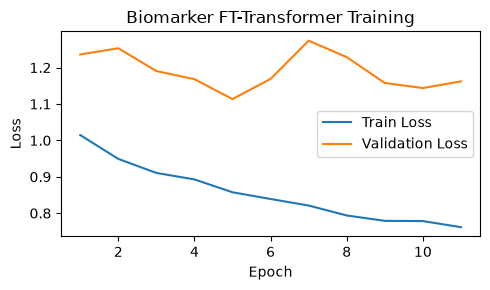

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

history_df = pd.DataFrame(
    history
)

display(history_df)

plt.figure(figsize=(5, 3))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Biomarker FT-Transformer Training")

plt.legend()
plt.tight_layout()
plt.show()